In [1]:
import pygrib
import pandas as pd
import numpy as np
import gudhi
import matplotlib.pyplot as plt


In [2]:
import pygrib
import pandas as pd

grbs = pygrib.open("hugedata.grib")
data = []

# Iterate over each GRIB message
for grb in grbs:
    # Check if this is the "U component of wind" message
    if "U component of wind" in grb.name:
        timestamp = pd.to_datetime(grb.validDate)  # Get timestamp
        values = grb.values  # This is a (1, 1440) array
        
        # Print the shape to confirm the structure
        
        # The values array has shape (1, 1440), so extract the 1D array (1440 values)
        for u in values[0]:  # This gives you the 1440 values in a 1D array
            data.append((timestamp, u))  # Append the timestamp and value to the data list

# Create a DataFrame with the collected data
df = pd.DataFrame(data, columns=["Timestamp", "U_Wind"])

# Sort the data by timestamp
df.sort_values(by="Timestamp", inplace=True)

# Reset the index
df.reset_index(drop=True, inplace=True)

# Display the first few rows of the DataFrame
print(df.head())

df.to_csv("vortex.csv")


   Timestamp     U_Wind
0 2015-01-01  -1.588669
1 2015-01-01  37.434769
2 2015-01-01  37.024612
3 2015-01-01  36.645706
4 2015-01-01  36.305862


KeyboardInterrupt: 

In [4]:
import numpy as np
import pandas as pd

# Example: Assuming df['U_Wind'] is your time series with 1440 values per hour.

# First, ensure that the data is sorted by the timestamp (if it's not already).
df['Date'] = pd.to_datetime(df['Timestamp'])
df.set_index('Date', inplace=True)

# Reshape the data: Group by the day (you may need to adjust this if your data isn't already grouped by hour)
# We'll group the data into daily chunks (each day will contain 1440 values)
daily_data = df['U_Wind'].resample('D').apply(lambda x: x.values)

# Apply a robust aggregation method:
# Option 1: Use the median (robust to outliers)
daily_median = daily_data.apply(np.median)

# Option 3: Use the trimean (a combination of the median and the mid-range)
def trimean(values):
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    return (q1 + 2 * np.median(values) + q3) / 4

daily_trimean = daily_data.apply(trimean)

# Example output: Show first few values of each aggregation method
print("Daily Median of U_Wind:")
print(daily_median.head())

print("Daily Trimean of U_Wind:")
print(daily_trimean.head())

# You can now use these daily values for further analysis or plotting.

KeyError: 'Timestamp'

In [126]:
daily_median

Date
2015-01-01    14.223877
2015-01-02     9.773323
2015-01-03     4.295074
2015-01-04     1.903404
2015-01-05    10.159531
                ...    
2020-12-27    23.971924
2020-12-28    23.117401
2020-12-29    22.934959
2020-12-30    22.787010
2020-12-31    22.788948
Freq: D, Name: U_Wind, Length: 2192, dtype: float64

In [127]:
df = daily_median

In [128]:
df = pd.DataFrame(df)
df['Date'] = df.index  # Add the datetime index as a 'Date' column if needed
df = df.set_index('Date')  # Set the 'Date' column as the index

In [38]:
df = pd.read_csv("polar_vortex_timeseries.csv")

In [47]:
df["Date"] = pd.to_datetime(df["Date"])

In [48]:
df

,Date,U_Wind
0,2015-01-01,14.223877
1,2015-01-02,9.773323
2,2015-01-03,4.295074
3,2015-01-04,1.903404
4,2015-01-05,10.159531
...,...,...
2187,2020-12-27,23.971924
2188,2020-12-28,23.117401
2189,2020-12-29,22.934959
2190,2020-12-30,22.787010


In [17]:
snowdata = pd.read_csv("montana_snow_timeseries.csv",index_col=0)
tempdata = pd.read_csv("montana_tmin_timeseries.csv",index_col=0)

In [18]:
snow_df = snowdata
temp_df = tempdata

In [22]:
temp_df

,State_Avg_TMIN
DATE,
2015-01-01,-133.121551
2015-01-02,-147.109833
2015-01-03,-172.253146
2015-01-04,-184.874156
2015-01-05,-147.859419
...,...
2024-12-27,-28.850301
2024-12-28,-13.842535
2024-12-29,-22.436665


In [24]:
temp_df.index

Index(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05',
       '2015-01-06', '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-10',
       ...
       '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26',
       '2024-12-27', '2024-12-28', '2024-12-29', '2024-12-30', '2024-12-31'],
      dtype='object', name='DATE', length=3653)

In [51]:
df['U_Wind']

0       14.223877
1        9.773323
2        4.295074
3        1.903404
4       10.159531
          ...    
2187    23.971924
2188    23.117401
2189    22.934959
2190    22.787010
2191    22.788948
Name: U_Wind, Length: 2192, dtype: float64

In [178]:
df.to_csv("polar_vortex_timeseries.csv")

In [45]:
temp_df["DATE"]

0      2015-01-01
1      2015-01-02
2      2015-01-03
3      2015-01-04
4      2015-01-05
          ...    
3648   2024-12-27
3649   2024-12-28
3650   2024-12-29
3651   2024-12-30
3652   2024-12-31
Name: DATE, Length: 3653, dtype: datetime64[ns]

In [34]:
temp_df = temp_df.reset_index()

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

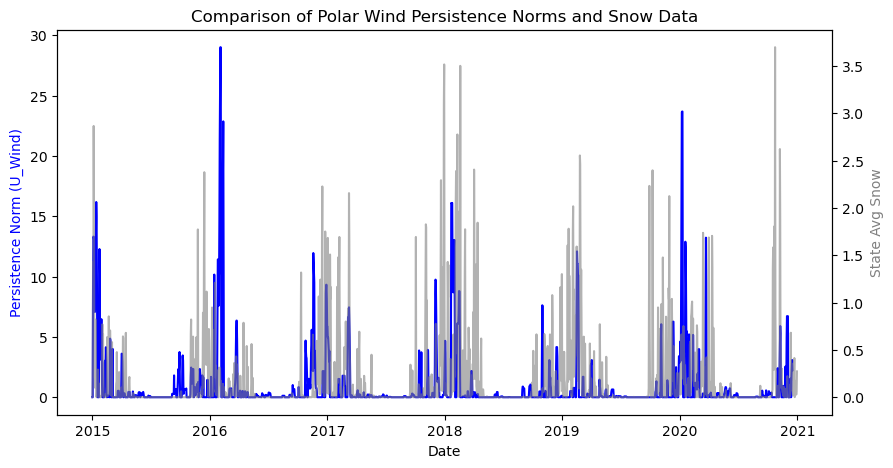

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import Landscape

# Parameters for Takens' embedding and sliding window
embedding_dim = 3  # Embedding dimension (m)
time_delay = 4     # Time delay (tau)
window_size = 14   # Sliding window size
max_dimension = 1  # Max dimension for persistence computation (usually 1 for loops)

# Convert Date columns to datetime
snow_df['DATE'] = pd.to_datetime(snow_df['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
snow_df_filtered = snow_df[(snow_df['DATE'] >= '2015-01-01') & (snow_df['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
snow_data_aligned = snow_df_filtered[snow_df_filtered['DATE'].isin(data1.index)]

# Plot persistence norms and snow data
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(data1.index[:len(norms)], norms, color='blue', label='Persistence Norm of U_Wind')
ax2.plot(snow_data_aligned['DATE'], snow_data_aligned['state_avg_snow'], color='gray', label='State Avg Snow', alpha=0.6)

# Labels and title
ax1.set_xlabel('Date')
ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
ax2.set_ylabel('State Avg Snow', color='gray')
plt.title('Comparison of Polar Wind Persistence Norms and Snow Data')

# Show plot
plt.show()

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

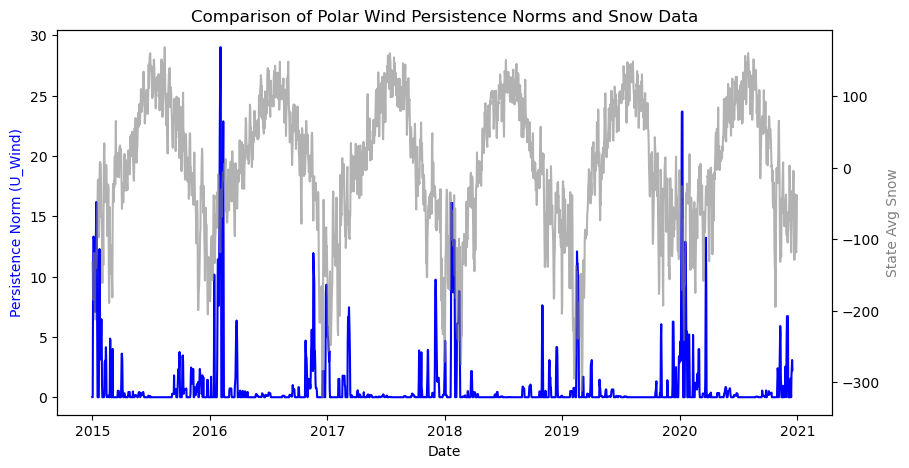

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import Landscape

# Parameters for Takens' embedding and sliding window
embedding_dim = 3  # Embedding dimension (m)
time_delay = 4     # Time delay (tau)
window_size = 14   # Sliding window size
max_dimension = 1  # Max dimension for persistence computation (usually 1 for loops)

# Use temp data instead
snow_df = temp_df.reset_index()
# Convert Date columns to datetime
snow_df['DATE'] = pd.to_datetime(snow_df['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
snow_df_filtered = snow_df[(snow_df['DATE'] >= '2015-01-01') & (snow_df['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
snow_data_aligned = snow_df_filtered[snow_df_filtered['DATE'].isin(data1.index)]

# Plot persistence norms and snow data
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(data1.index[:len(norms)], norms, color='blue', label='Persistence Norm of U_Wind')
ax2.plot(snow_data_aligned['DATE'], snow_data_aligned['State_Avg_TMIN'], color='gray', label='State Avg Snow', alpha=0.6)

# Labels and title
ax1.set_xlabel('Date')
ax1.set_ylabel('Persistence Norm (U_Wind)', color='blue')
ax2.set_ylabel('State Avg Snow', color='gray')
plt.title('Comparison of Polar Wind Persistence Norms and Snow Data')

# Show plot
plt.show()

In [ ]:
# Years seperate

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

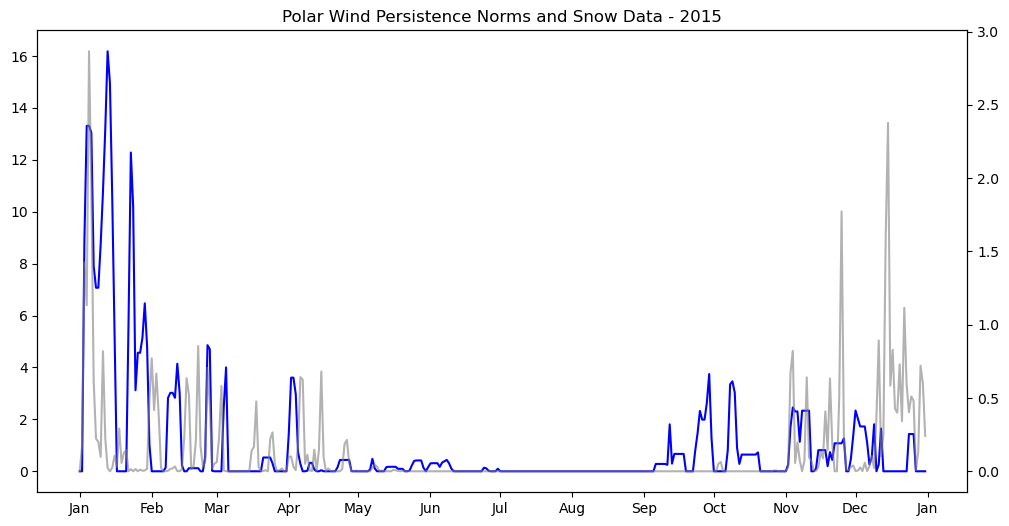

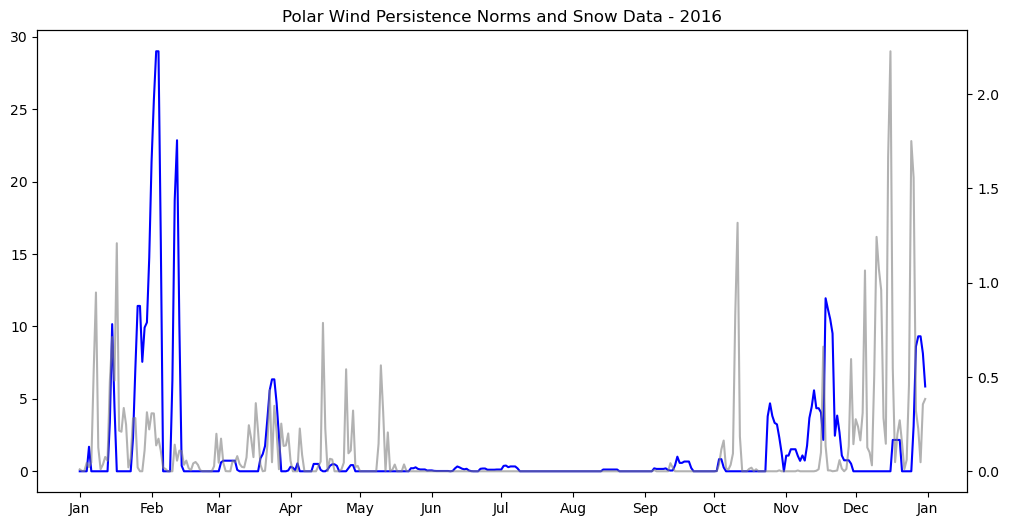

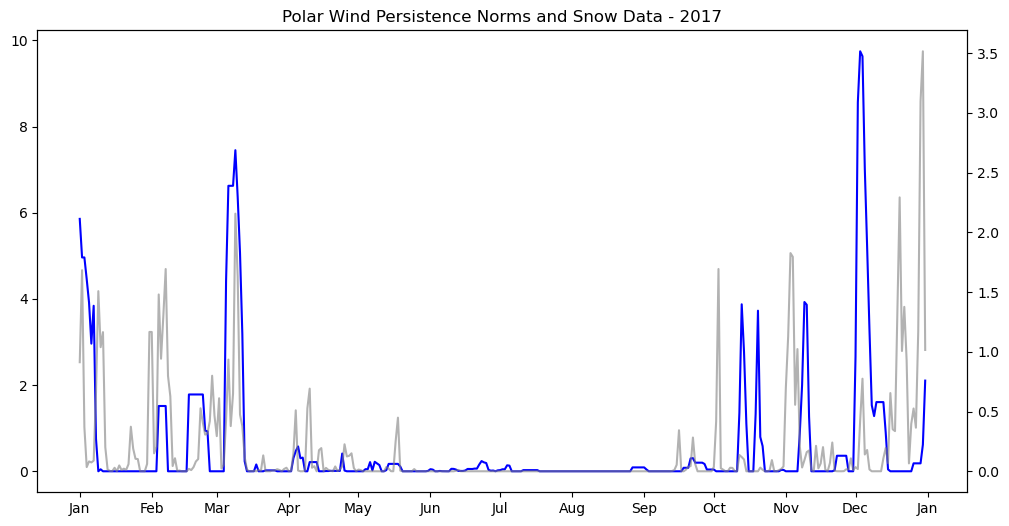

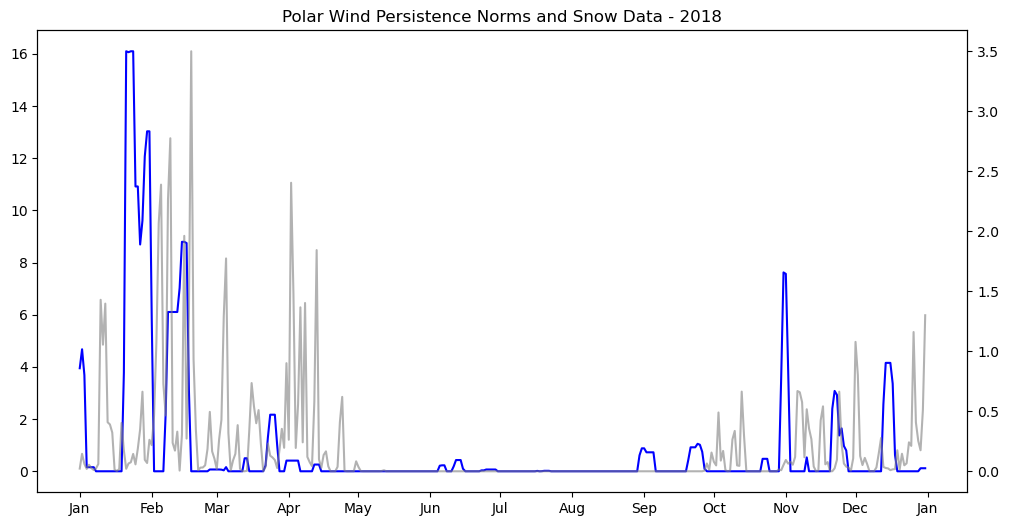

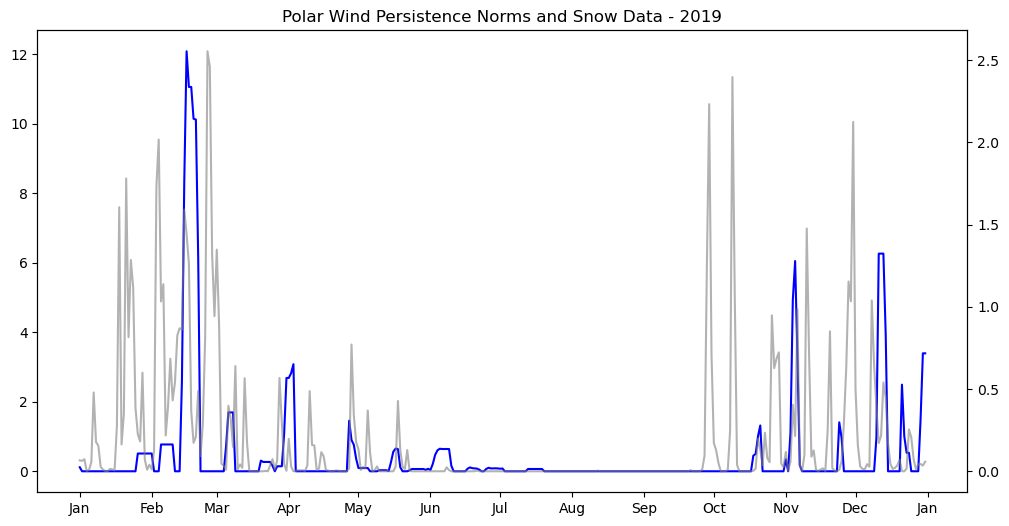

ValueError: x and y must have same first dimension, but have shapes (366,) and (352,)

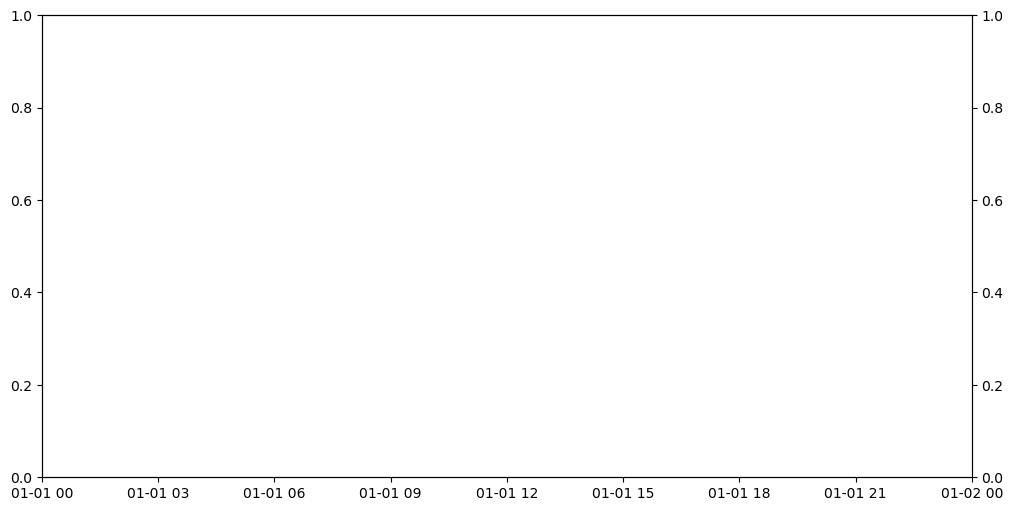

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import Landscape
import matplotlib.dates as mdates

# Parameters for Takens' embedding and sliding window
embedding_dim = 3  # Embedding dimension (m)
time_delay = 4     # Time delay (tau)
window_size = 14   # Sliding window size
max_dimension = 1  # Max dimension for persistence computation (usually 1 for loops)


#Read proper data
snow_df = pd.read_csv("montana_snow_timeseries.csv")
# Convert Date columns to datetime
snow_df['DATE'] = pd.to_datetime(snow_df['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
snow_df_filtered = snow_df[(snow_df['DATE'] >= '2015-01-01') & (snow_df['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
snow_data_aligned = snow_df_filtered[snow_df_filtered['DATE'].isin(data1.index)]

# Generate plots for each year from 2015 to 2020
for year in range(2015, 2021):
    yearly_data = data1[(data1.index >= f'{year}-01-01') & (data1.index <= f'{year}-12-31')]
    yearly_norms = norms[:len(yearly_data)]  # Align norms to yearly data
    norms = norms[len(yearly_data):]  # Shift norms for the next year
    yearly_snow = snow_data_aligned[(snow_data_aligned['DATE'] >= f'{year}-01-01') & (snow_data_aligned['DATE'] <= f'{year}-12-31')]
    
    fig, ax1 = plt.subplots(figsize=(12, 6))  # Full-sized plot for each year
    ax2 = ax1.twinx()
    
    ax1.plot(yearly_data.index, yearly_norms, color='blue', label='Persistence Norm of U_Wind')
    ax2.plot(yearly_snow['DATE'], yearly_snow['state_avg_snow'], color='gray', label='State Avg Snow', alpha=0.6)
    
    # Format x-axis to show months
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    # Add month labels
    plt.xticks(rotation=45)
    
    plt.title(f'Polar Wind Persistence Norms and Snow Data - {year}')
    plt.show()


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gudhi as gd
from gudhi.representations import Landscape
import matplotlib.dates as mdates

# Parameters for Takens' embedding and sliding window
embedding_dim = 3  # Embedding dimension (m)
time_delay = 4     # Time delay (tau)
window_size = 14   # Sliding window size
max_dimension = 1  # Max dimension for persistence computation (usually 1 for loops)

#Read proper data
snow_df = pd.read_csv("montana_tmin_timeseries.csv").reset_index()

# Convert Date columns to datetime
snow_df['DATE'] = pd.to_datetime(snow_df['DATE'], format='%m/%d/%Y')
df['Date'] = pd.to_datetime(df['Date'])

# Filter data from 2015 to 2020
df_filtered = df[(df['Date'] >= '2015-01-01') & (df['Date'] <= '2020-12-31')]
snow_df_filtered = snow_df[(snow_df['DATE'] >= '2015-01-01') & (snow_df['DATE'] <= '2020-12-31')]

# Ensure data is indexed by date
df_filtered = df_filtered.set_index('Date')
data1 = df_filtered['U_Wind']

# Initialize an array to store the persistence diagrams
dgms = np.empty(len(data1) - window_size, dtype=object)

# Sliding window with Takens' embedding
for i in range(len(data1) - window_size):
    window = data1[i:i + window_size].values  # Get a window of daily values
    X = np.zeros((window_size - time_delay, time_delay), dtype=float)  # Prepare array for embedding

    # Takens' embedding: Create embedded vectors
    for j in range(window_size - time_delay):
        X[j, :] = window[j:j + time_delay]

    # Compute Rips Complex and persistence diagram
    rc = gd.RipsComplex(points=X).create_simplex_tree(max_dimension=2)
    rc.persistence()
    dgm = rc.persistence_intervals_in_dimension(1)  # Extract persistence diagram for dimension 1 (loops)
    dgms[i] = dgm

# Compute the norms of the landscapes
norms = np.zeros(dgms.shape[0])  # Array to store norms of the landscapes
for i in range(dgms.shape[0]):
    l = Landscape(num_landscapes=2, resolution=10).fit_transform([dgms[i]])
    norms[i] = np.linalg.norm(l[0])  # Compute the norm of the first landscape

# Align the snow data
snow_data_aligned = snow_df_filtered[snow_df_filtered['DATE'].isin(data1.index)]

# Generate plots for each year from 2015 to 2020
for year in range(2015, 2021):
    yearly_data = data1[(data1.index >= f'{year}-01-01') & (data1.index <= f'{year}-12-31')]
    yearly_norms = norms[:len(yearly_data)]  # Align norms to yearly data
    norms = norms[len(yearly_data):]  # Shift norms for the next year
    yearly_snow = snow_data_aligned[(snow_data_aligned['DATE'] >= f'{year}-01-01') & (snow_data_aligned['DATE'] <= f'{year}-12-31')]
    
    fig, ax1 = plt.subplots(figsize=(12, 6))  # Full-sized plot for each year
    ax2 = ax1.twinx()
    
    ax1.plot(yearly_data.index, yearly_norms, color='blue', label='Persistence Norm of U_Wind')
    ax2.plot(yearly_snow['DATE'], yearly_snow['state_avg_snow'], color='gray', label='State Avg Snow', alpha=0.6)
    
    # Format x-axis to show months
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    # Add month labels
    plt.xticks(rotation=45)
    
    plt.title(f'Polar Wind Persistence Norms and Snow Data - {year}')
    plt.show()


ValueError: time data "2015-01-01" doesn't match format "%m/%d/%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.